In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append("..")
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

from src.data import load_adult
from src.explain import load_tuned_params, fit_xgb, explain_shap, global_importance

os.makedirs("../results", exist_ok=True)
os.makedirs("../figures", exist_ok=True)
X_train, X_test, y_train, y_test = load_adult()
params = load_tuned_params()

In [ ]:
# Fit the model and check that SHAP agrees with the pipeline's predictions
pipe = fit_xgb(X_train, y_train, params)
X_s = X_train.sample(2000, random_state=42)
out = explain_shap(pipe, X_s)      # raises if SHAP disagrees with pipe.predict_proba
grouped = out["grouped"]
print("grouped shape:", grouped.shape)

SHAP check passed; grouped shape: (2000, 13)


In [3]:
import src.explain as ex
print("fitted preprocessor sparse_threshold:", pipe[0].sparse_threshold, "(want 0)")
has_check = any("different function" in str(c) for c in ex.explain_shap.__code__.co_consts)
print("loaded explain_shap has pipeline check:", has_check, "(want True)")
Zs = pipe[0].transform(X_s)
print("pipeline preprocessor output sparse:", hasattr(Zs, "toarray"), "(want False)")
assert pipe[0].sparse_threshold == 0 and has_check, "stale modules: restart the kernel"

fitted preprocessor sparse_threshold: 0 (want 0)
loaded explain_shap has pipeline check: True (want True)
pipeline preprocessor output sparse: False (want False)


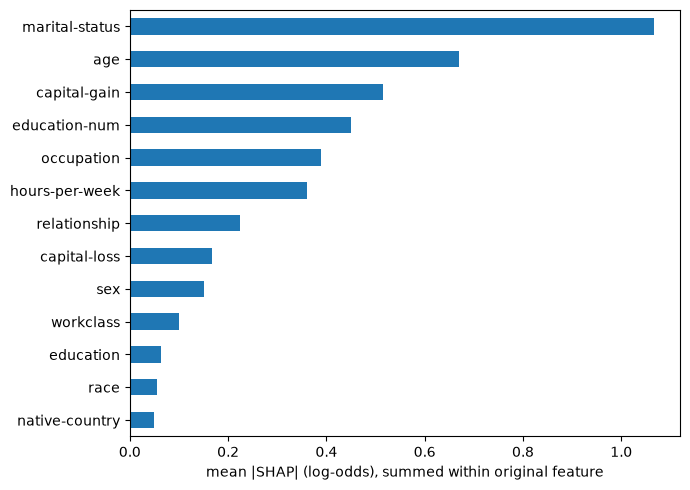

marital-status    1.066
age               0.669
capital-gain      0.515
education-num     0.451
occupation        0.389
hours-per-week    0.361
relationship      0.224
capital-loss      0.166
sex               0.152
workclass         0.100
education         0.064
race              0.056
native-country    0.048
dtype: float32

In [4]:
# Compute global importance and save results
imp = global_importance(grouped)
imp.to_csv("../results/shap_global_importance.csv", header=["mean_abs_shap"])

fig, ax = plt.subplots(figsize=(7, 5))
imp.sort_values().plot.barh(ax=ax)
ax.set_xlabel("mean |SHAP| (log-odds), summed within original feature")
fig.tight_layout()
fig.savefig("../figures/shap_global_bar.png", dpi=150)
plt.show()
imp.round(3)

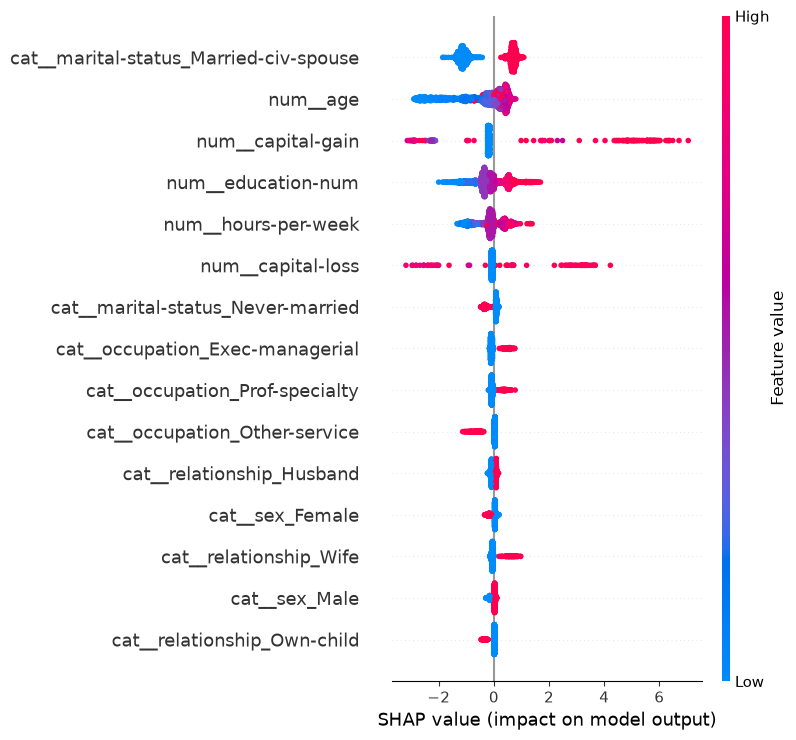

In [5]:
# Create a beeswarm plot of SHAP values
shap.summary_plot(out["values"], out["Z"], feature_names=out["names"],
                  max_display=15, show=False)
plt.gcf().savefig("../figures/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

row index: 28766 | P(>50K) = 0.5 | true label: 0
f(x) from SHAP: -0.001 | logit of pipeline proba: -0.001


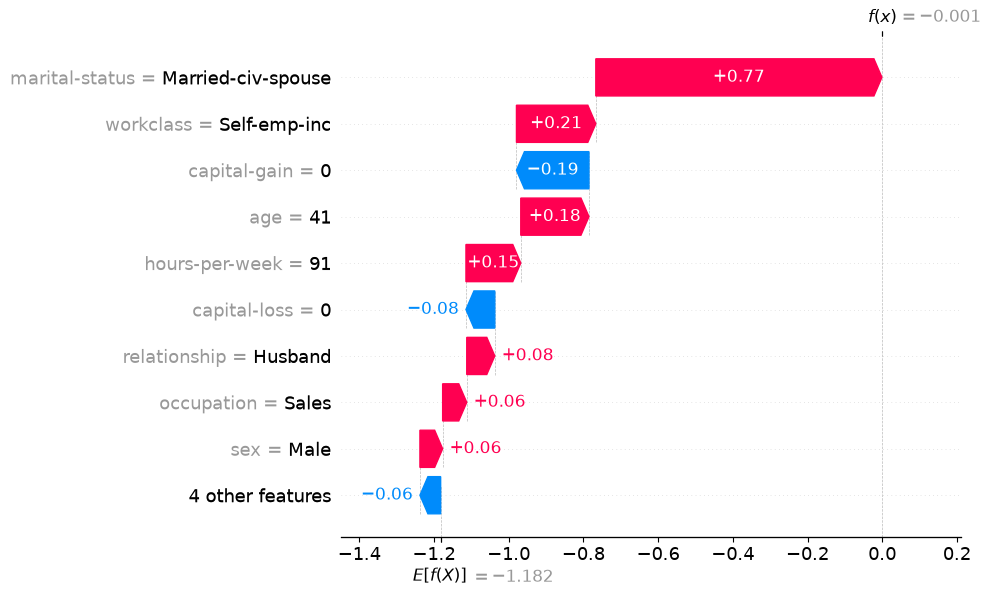

In [6]:
# Explain a single instance with a waterfall plot
proba = pipe.predict_proba(X_s)[:, 1]
pos = int(np.argmin(np.abs(proba - 0.5)))
idx = X_s.index[pos]
p = float(proba[pos])
print("row index:", idx, "| P(>50K) =", round(p, 3), "| true label:", int(y_train.loc[idx]))

fx = out["base_value"] + float(grouped.loc[idx].sum())
logit = float(np.log(p / (1 - p)))
print("f(x) from SHAP:", round(fx, 3), "| logit of pipeline proba:", round(logit, 3))
assert abs(fx - logit) < 1e-2, "waterfall would explain the wrong row/function"

cols = list(X_s.columns)
labels = [f"{c} = {X_s.loc[idx, c]}" for c in cols]
expl = shap.Explanation(values=grouped.loc[idx, cols].values,
                        base_values=out["base_value"], feature_names=labels)
shap.plots.waterfall(expl, max_display=10, show=False)
plt.gcf().savefig("../figures/shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

with open("../results/explained_instance.json", "w") as f:
    json.dump({"train_row_index": int(idx), "proba": p}, f)

In [7]:
# Compare SHAP and permutation importance
Xa, Xv, ya, yv = train_test_split(X_train, y_train, test_size=0.25,
                                  stratify=y_train, random_state=0)
pipe_a = fit_xgb(Xa, ya, params)
pi = permutation_importance(pipe_a, Xv, yv, scoring="roc_auc",
                            n_repeats=10, random_state=0, n_jobs=1)
perm = pd.DataFrame({"AUC drop": pi.importances_mean, "std": pi.importances_std},
                    index=Xv.columns).sort_values("AUC drop", ascending=False)
perm.to_csv("../results/permutation_importance.csv")

compare = pd.DataFrame({"SHAP rank": imp.rank(ascending=False),
                        "permutation rank": perm["AUC drop"].rank(ascending=False)}
                       ).sort_values("SHAP rank")
compare

,SHAP rank,permutation rank
marital-status,1.0,1.0
age,2.0,3.0
capital-gain,3.0,2.0
education-num,4.0,4.0
occupation,5.0,5.0
hours-per-week,6.0,7.0
relationship,7.0,8.0
capital-loss,8.0,6.0
sex,9.0,10.0
workclass,10.0,9.0
